In [1]:
library(cooccur)

# Demo on built in dataset

[1] 13 17
                         Seymour Baltra Isabella Fernandina Santiago
Geospiza magnirostris          0      0        1          1        1
Geospiza fortis                1      1        1          1        1
Geospiza fuliginosa            1      1        1          1        1
Geospiza difficilis            0      0        1          1        1
Geospiza scandens              1      1        1          0        1
Geospiza conirostris           0      0        0          0        0
Camarhynchus psittacula        0      0        1          1        1
Camarhynchus pauper            0      0        0          0        0
Camarhynchus parvulus          0      0        1          1        1
Platyspiza crassirostris       0      0        1          1        1


[1] 13 17
                         Seymour Baltra Isabella Fernandina Santiago
Geospiza magnirostris          0      0        1          1        1
Geospiza fortis                1      1        1          1        1
Geospiza fuliginosa            1      1        1          1        1
Geospiza difficilis            0      0        1          1        1
Geospiza scandens              1      1        1          0        1
Geospiza conirostris           0      0        0          0        0
Camarhynchus psittacula        0      0        1          1        1
Camarhynchus pauper            0      0        0          0        0
Camarhynchus parvulus          0      0        1          1        1
Platyspiza crassirostris       0      0        1          1        1


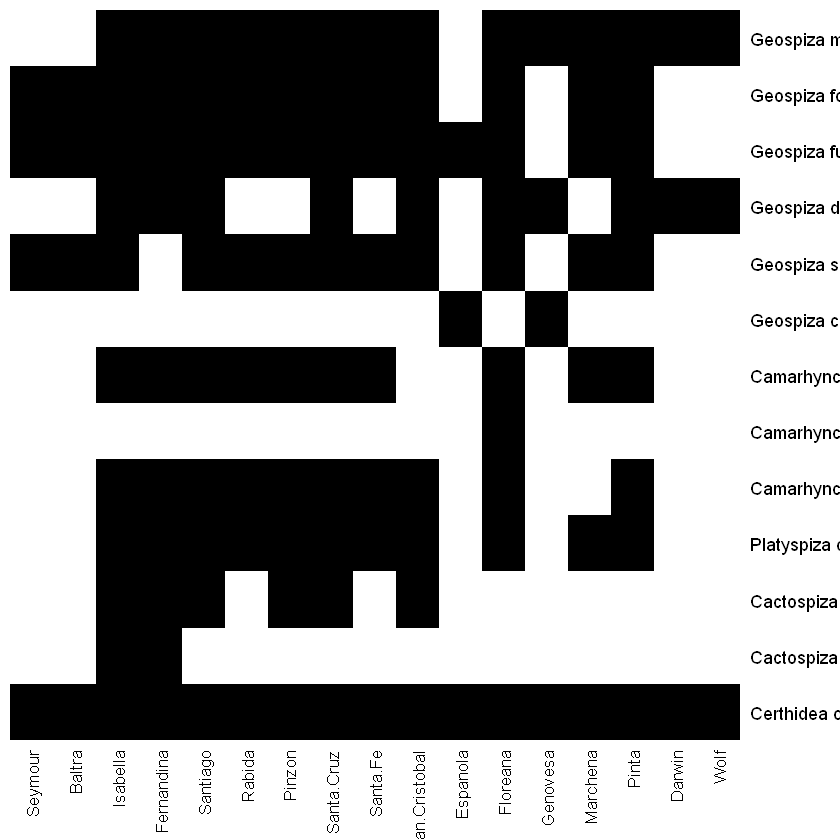

In [50]:
data(finches)
df <- finches

print(dim(df))
print(df[1:10, 1:5])

heatmap(as.matrix(df)[nrow(df):1, ], col = c("white", "black"), scale = "none",
        Rowv = NA, Colv = NA)

In [59]:

result <- cooccur(mat = df,
                  type = "spp_site",  # species in rows, sites in cols
                  thresh = TRUE,      # filter rare species pairs
                  spp_names = TRUE)   # use species names

summary(result)  # summarize overall co-occurrence results


  |======================================================================| 100%
Call:
cooccur(mat = finches, type = "spp_site", thresh = TRUE, spp_names = TRUE)

Of 78 species pair combinations, 14 pairs (17.95 %) were removed from the analysis because expected co-occurrence was < 1 and 64 pairs were analyzed

Cooccurrence Summary:


       Species          Sites       Positive       Negative         Random 
          13.0           17.0           14.0            1.0           42.0 
Unclassifiable Non-random (%) 
           7.0           23.4 
attr(,"class")
[1] "summary.cooccur"

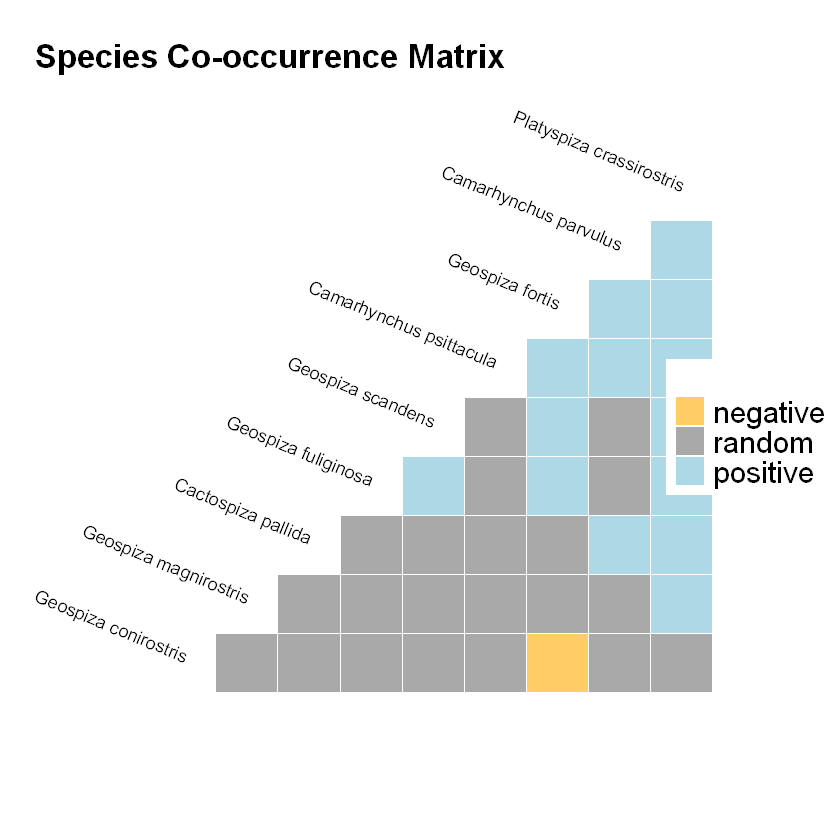

In [60]:
plot(result)  # plot species pairwise co-occurrence patterns

In [61]:
prob.table(result)[1:5, ]  # pairwise co-occurrence probabilities: obs/exp counts and p-values for each species pair

Warning message in prob.table(result):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"


,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,1,2,14,13,11,0.630,10.7,0.87941,0.57941,Geospiza magnirostris,Geospiza fortis
2,1,3,14,14,11,0.678,11.5,0.53529,1.00000,Geospiza magnirostris,Geospiza fuliginosa
3,1,4,14,10,10,0.484,8.2,1.00000,0.05147,Geospiza magnirostris,Geospiza difficilis
4,1,5,14,12,10,0.581,9.9,0.80882,0.67647,Geospiza magnirostris,Geospiza scandens
5,1,6,14,2,1,0.097,1.6,0.33088,0.97794,Geospiza magnirostris,Geospiza conirostris


In [62]:
# top 5 significant negative associations (p_lt = observed < or > expected)
prob.table(result)[order(prob.table(result)$p_lt), ][1:5, ]
prob.table(result)[order(prob.table(result)$p_gt), ][1:5, ]

Warning message in prob.table(result):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"
Warning message in prob.table(result):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"


,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
15,2,6,13,2,0,0.090,1.5,0.04412,1,Geospiza fortis,Geospiza conirostris
39,5,6,12,2,0,0.083,1.4,0.07353,1,Geospiza scandens,Geospiza conirostris
48,6,10,2,11,0,0.076,1.3,0.11029,1,Geospiza conirostris,Platyspiza crassirostris
46,6,7,2,10,0,0.069,1.2,0.15441,1,Geospiza conirostris,Camarhynchus psittacula
47,6,9,2,10,0,0.069,1.2,0.15441,1,Geospiza conirostris,Camarhynchus parvulus


Warning message in prob.table(result):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"
Warning message in prob.table(result):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"


,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
51,7,10,10,11,10,0.381,6.5,1.00000,0.00057,Camarhynchus psittacula,Platyspiza crassirostris
56,9,10,10,11,10,0.381,6.5,1.00000,0.00057,Camarhynchus parvulus,Platyspiza crassirostris
14,2,5,13,12,12,0.540,9.2,1.00000,0.00210,Geospiza fortis,Geospiza scandens
50,7,9,10,10,9,0.346,5.9,0.99995,0.00365,Camarhynchus psittacula,Camarhynchus parvulus
12,2,3,13,14,13,0.630,10.7,1.00000,0.00588,Geospiza fortis,Geospiza fuliginosa


In [63]:
pair.attributes(result) # result summary by species

,pos,neg,rand,num_pos,num_neg,num_rand,sppname
,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<chr>
1,9.09,0.00,90.91,1,0,10,Geospiza magnirostris
6,45.45,9.09,45.45,5,1,5,Geospiza fortis
7,27.27,0.00,72.73,3,0,8,Geospiza fuliginosa
8,0.00,0.00,100.00,0,0,11,Geospiza difficilis
9,27.27,0.00,72.73,3,0,8,Geospiza scandens
10,0.00,11.11,88.89,0,1,8,Geospiza conirostris
11,27.27,0.00,72.73,3,0,8,Camarhynchus psittacula
12,0.00,0.00,100.00,0,0,1,Camarhynchus pauper
13,36.36,0.00,63.64,4,0,7,Camarhynchus parvulus


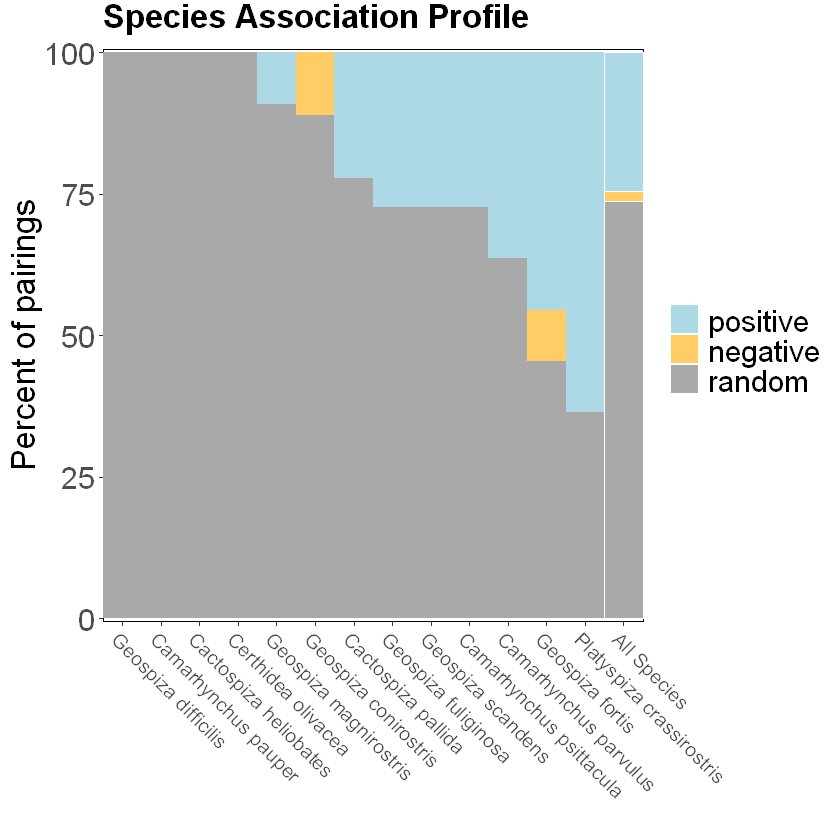

In [64]:
pair.profile(result) # species interaction profile visualization

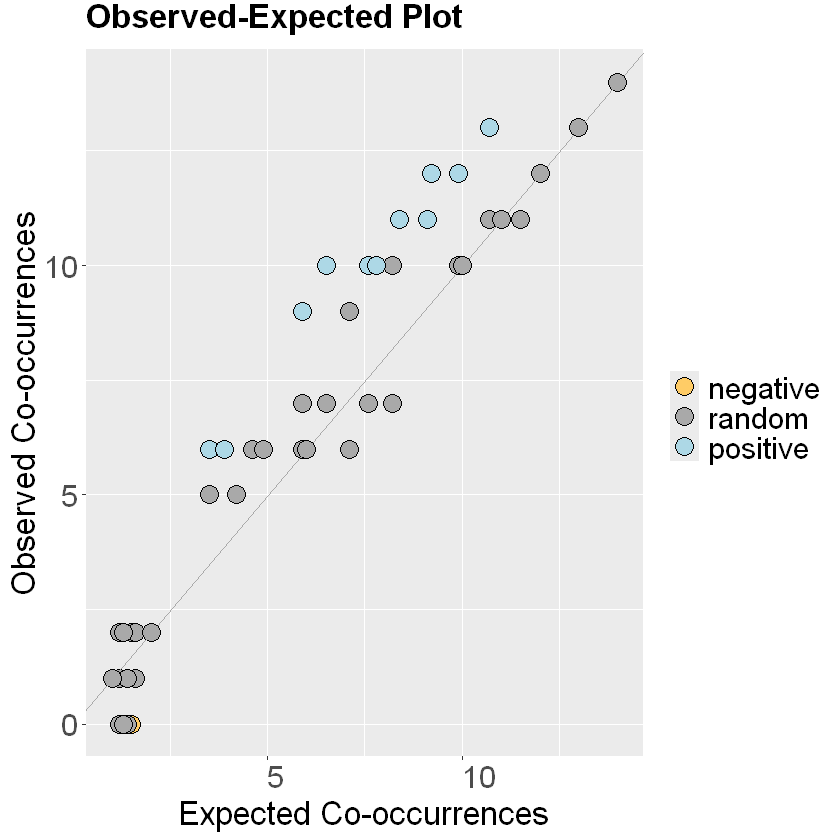

In [65]:
obs.v.exp(result) # observed vs expected co-occurrence comparison

In [68]:
round(effect.sizes(result,matrix=TRUE),3) # effect sizes (standardized residuals) for each species pair; values > 2 or < -2 indicate significant positive or negative associations, respectively

                         Geospiza magnirostris Geospiza fortis
Geospiza fortis                          0.018                
Geospiza fuliginosa                     -0.029           0.135
Geospiza difficilis                      0.106          -0.035
Geospiza scandens                        0.006           0.165
Geospiza conirostris                    -0.035          -0.088
Camarhynchus psittacula                  0.106           0.141
Camarhynchus pauper                         NA              NA
Camarhynchus parvulus                    0.106           0.141
Platyspiza crassirostris                 0.112           0.153
Cactospiza pallida                       0.065           0.082
Cactospiza heliobates                    0.024           0.029
Certhidea olivacea                       0.000           0.000
                         Geospiza fuliginosa Geospiza difficilis
Geospiza fortis                                                 
Geospiza fuliginosa                                

In [70]:
pair(mod = result, "Geospiza fortis", all=TRUE)  # pairwise stats for focal species

Species:
[1] "Geospiza fortis"
with 11 associations

                        sp2 sp2_inc obs_cooccur prob_cooccur exp_cooccur
12      Geospiza fuliginosa      14          13        0.630        10.7
13      Geospiza difficilis      10           7        0.450         7.6
14        Geospiza scandens      12          12        0.540         9.2
15     Geospiza conirostris       2           0        0.090         1.5
16  Camarhynchus psittacula      10          10        0.450         7.6
17    Camarhynchus parvulus      10          10        0.450         7.6
18 Platyspiza crassirostris      11          11        0.495         8.4
19       Cactospiza pallida       6           6        0.270         4.6
20    Cactospiza heliobates       2           2        0.090         1.5
21       Certhidea olivacea      17          13        0.765        13.0
1     Geospiza magnirostris      14          11        0.630        10.7
      p_lt    p_gt
12 1.00000 0.00588
13 0.44118 0.91176
14 1.00000 0.0

# Pre-carp analysis ($\leq 2007$)

In [80]:
library(cooccur)

############################
# load data
############################
df <- read.csv("pres_abs.csv", header=TRUE)
ind <- which(df[1,2:ncol(df)] <= 2007)+1 # before breakpoint
df <- df[,c(1,ind)]
colnames(df) <- paste(colnames(df), df[1, ], sep = "_")
df <- df[3:nrow(df), ]
rownames(df) <- df[,1]  
df <- df[, -1]

df <- df[rowSums(df) > 0, ] # remove species with no occurrences
print(dim(df))
print(df[1:5, 1:5])

df <- df[, colSums(df) >= 25]    # reduces site count
df <- df[rowSums(df) >= 0.1*ncol(df), ]   # reduces species count
print(dim(df))

[1]   87 1040
     A10A.RS_1997 A10A.RS.1_2003 A12A.RS_1995 A12A.RS.1_2002 A6A.RS_2003
AMEL            0              0            0              0           0
BHCP            0              0            0              0           0
BHMW            0              0            0              0           0
BKBF            0              0            0              0           0
BKBH            0              0            0              0           0
[1] 52 52


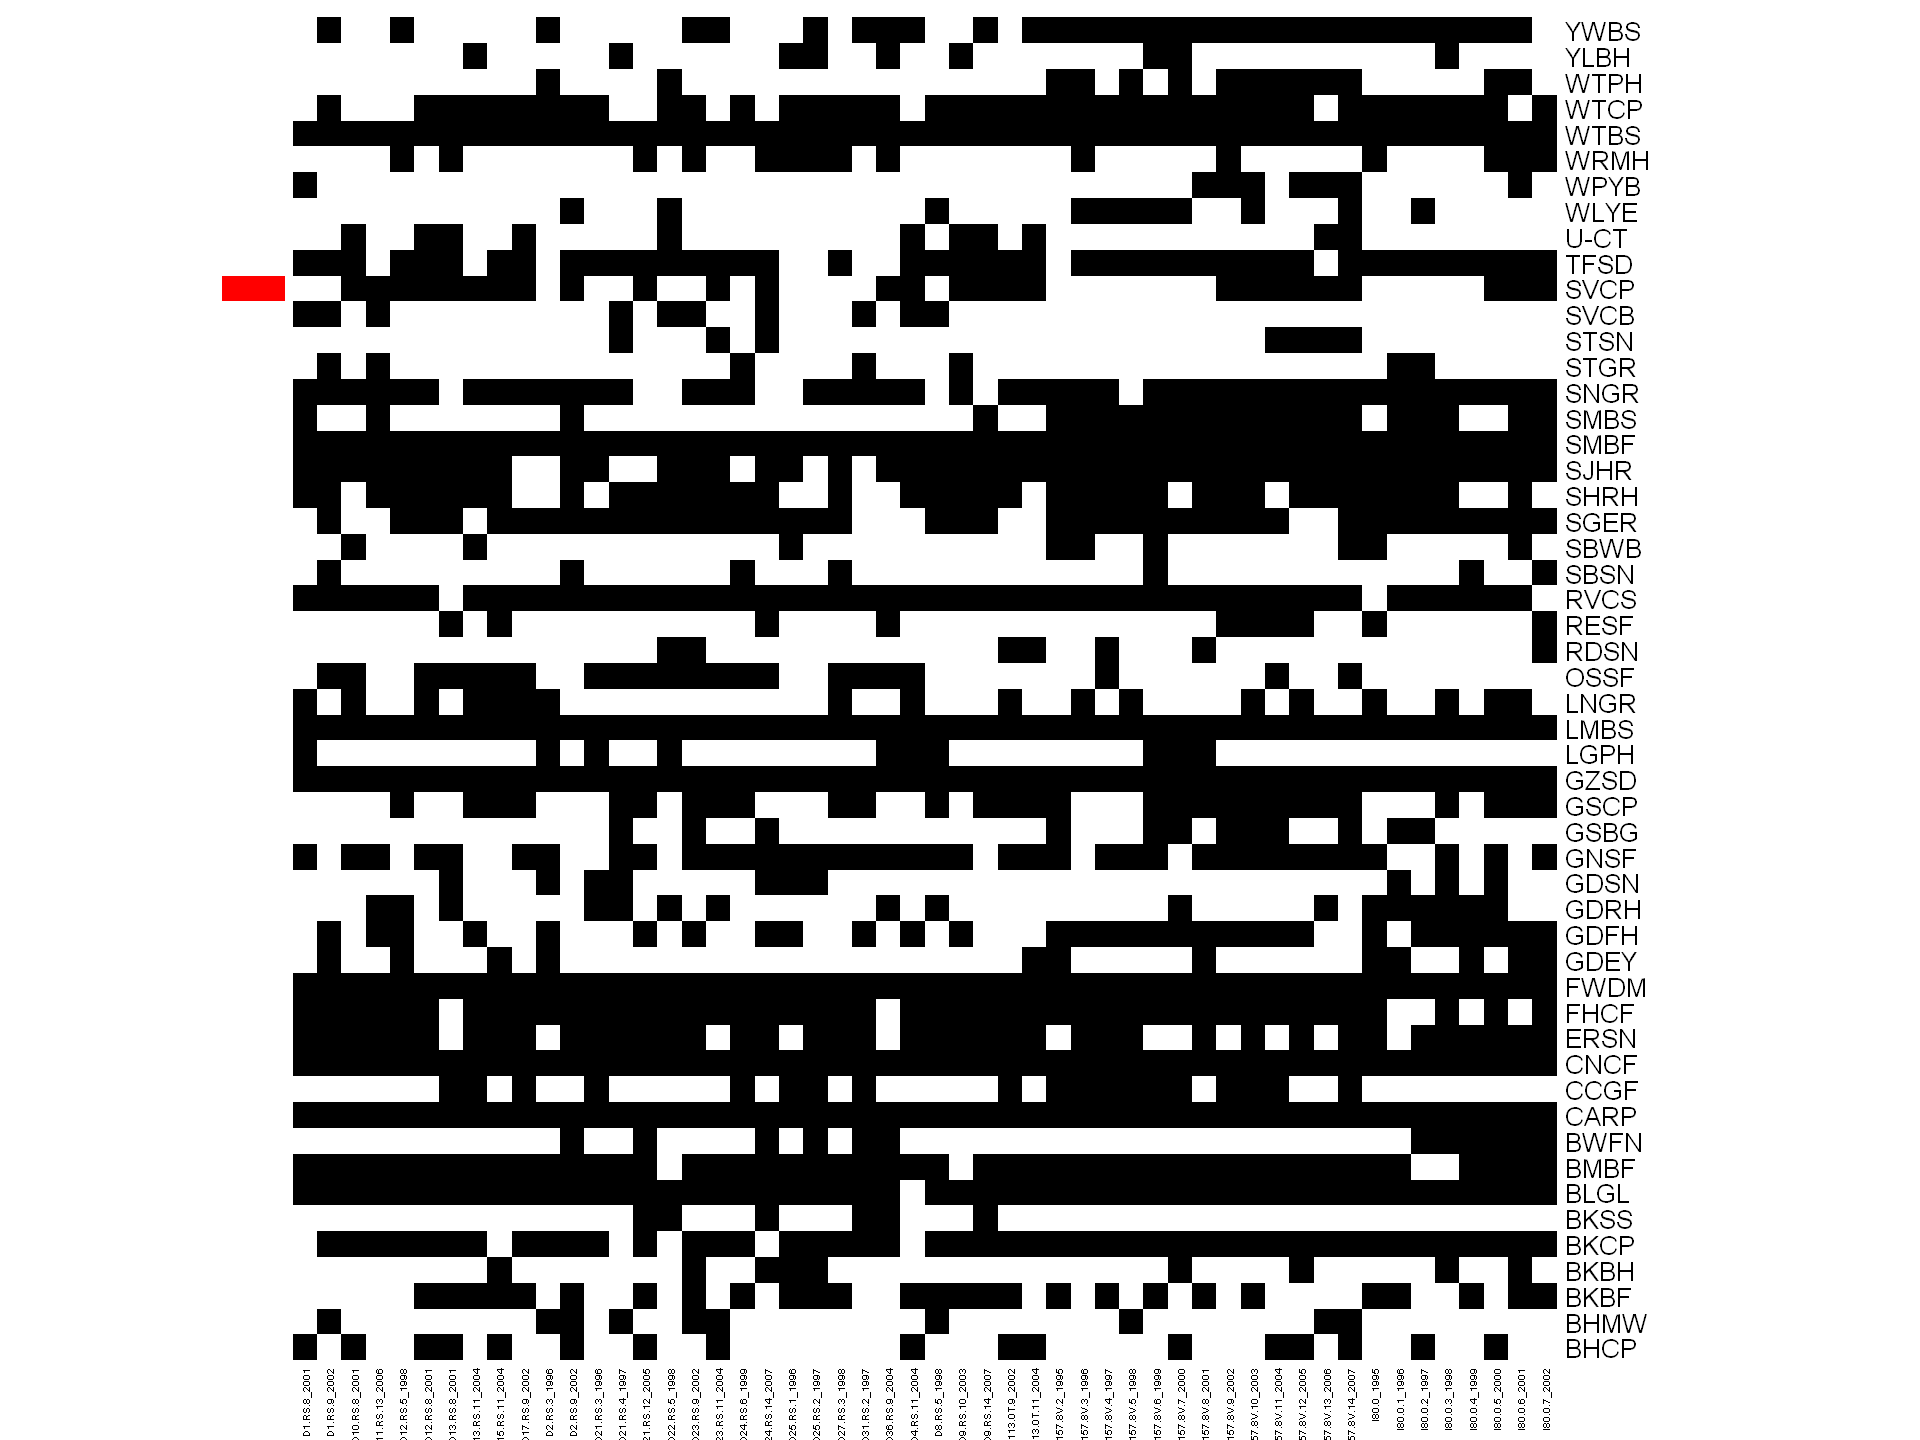

In [81]:
row_colors <- ifelse(rownames(df) == "SVCP", "red", "white")
options(repr.plot.width = 16, repr.plot.height = 12)
heatmap(as.matrix(df), col = c("white", "black"), scale = "none",
        Rowv = NA, Colv = NA, cexRow = 2.0, margins = c(5, 10),
        RowSideColors = row_colors)

In [82]:
result <- cooccur(mat = df,
                  type = "spp_site",  # species in rows, sites in cols
                  thresh = TRUE,      # filter rare species pairs
                  spp_names = TRUE,  # use species names
                   true_rand_classifier = 0.1)  # use a more stringent threshold for classifying random pairs (default is 0.5)

summary(result)  # summarize overall co-occurrence results


  |======================================================================| 100%
Call:
cooccur(mat = df, type = "spp_site", thresh = TRUE, spp_names = TRUE, 
    true_rand_classifier = 0.1)

Of 1326 species pair combinations, 11 pairs (0.83 %) were removed from the analysis because expected co-occurrence was < 1 and 1315 pairs were analyzed

Cooccurrence Summary:


       Species          Sites       Positive       Negative         Random 
          52.0           52.0           36.0           31.0         1248.0 
Unclassifiable Non-random (%) 
           0.0            5.1 
attr(,"class")
[1] "summary.cooccur"

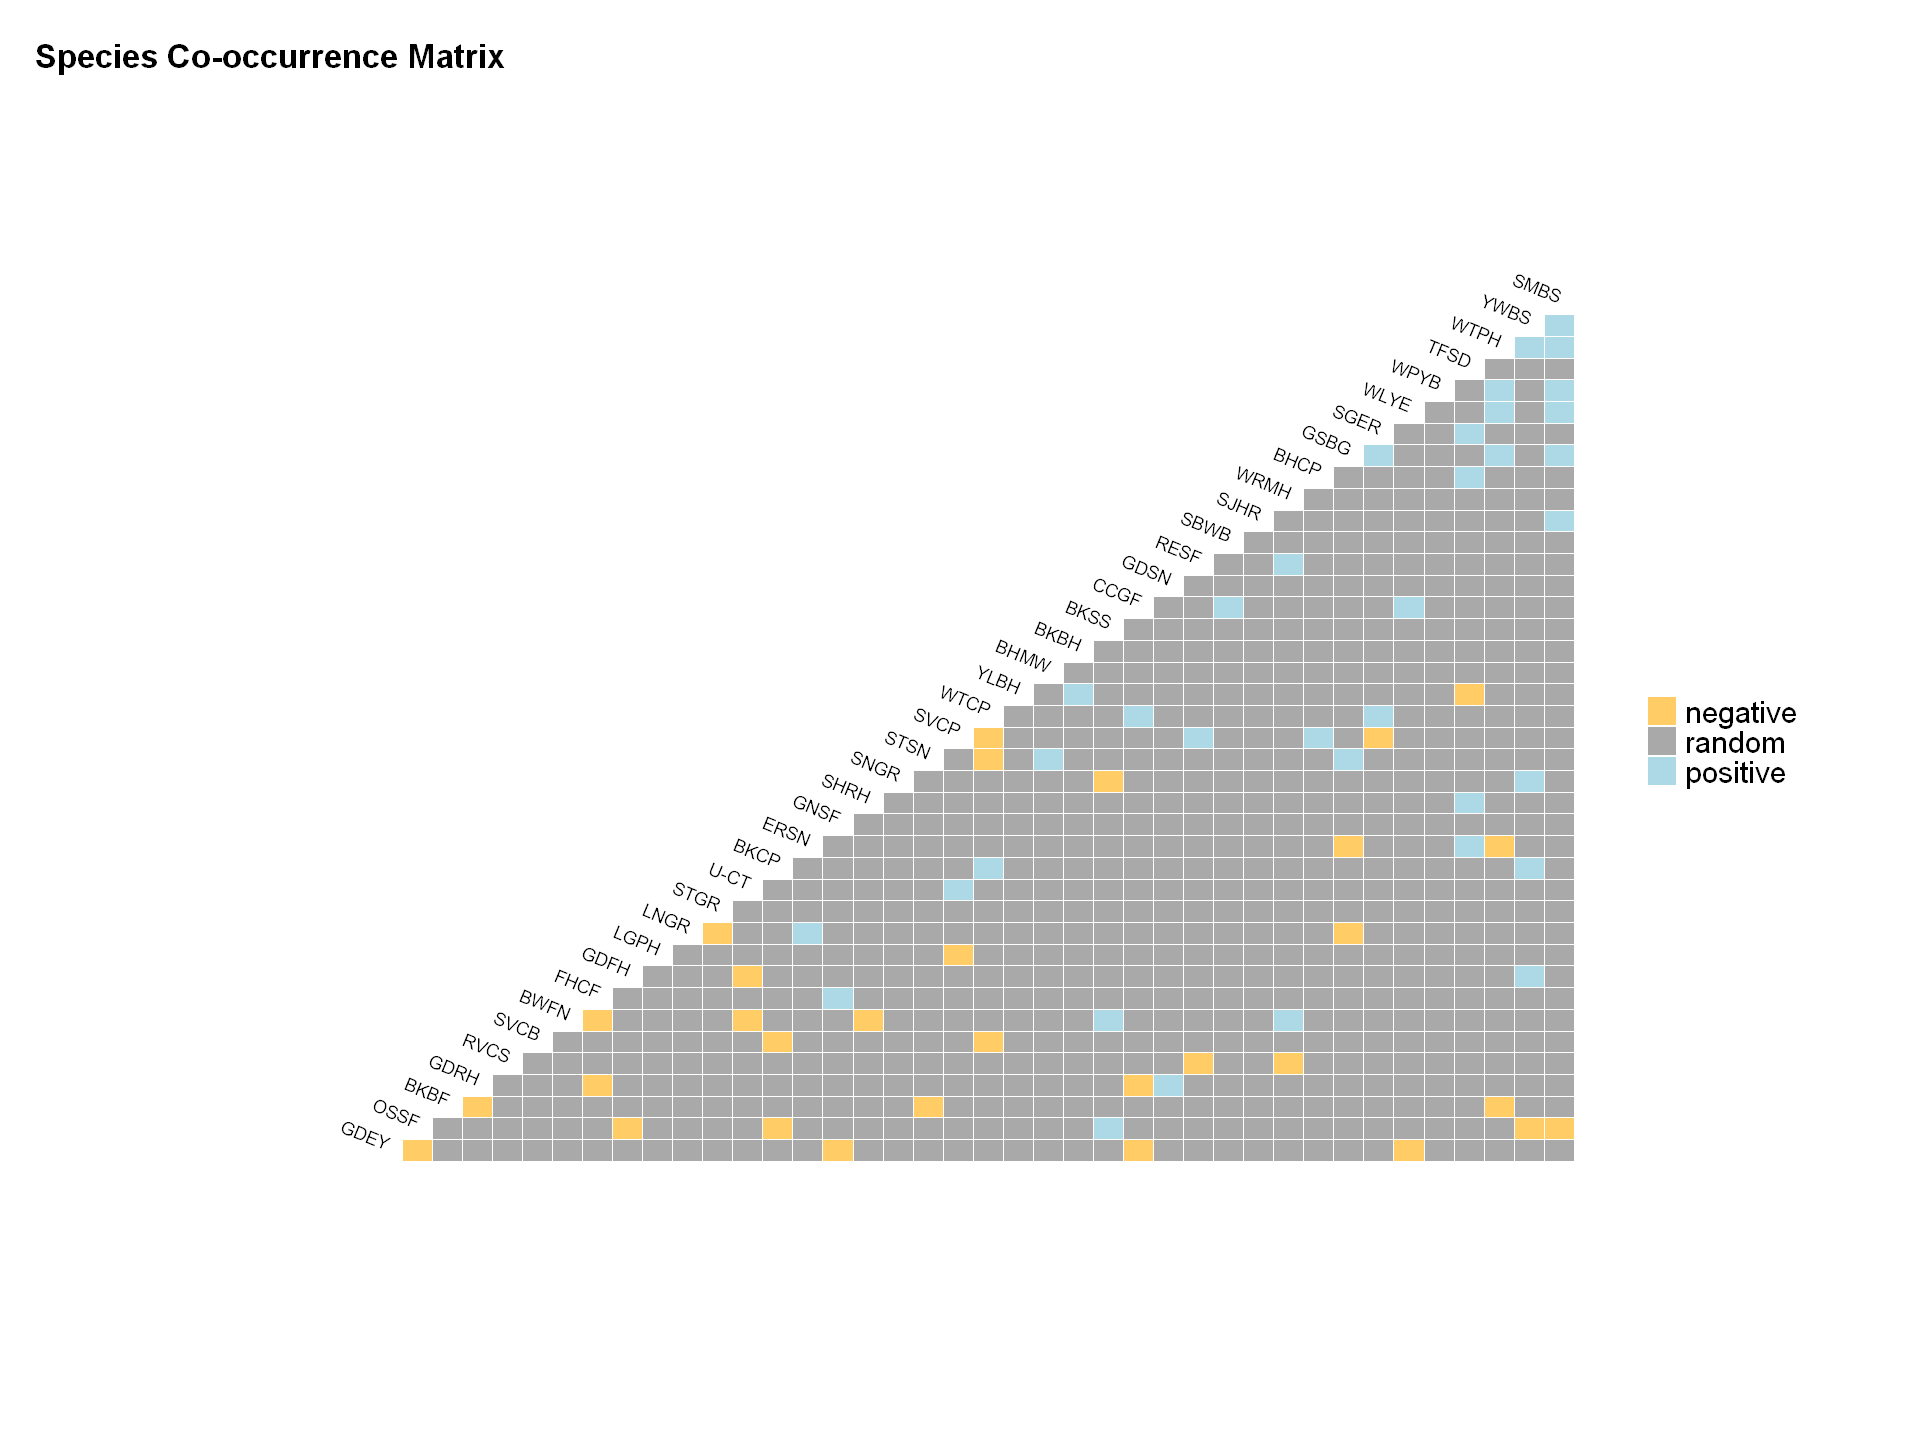

In [83]:
plot(result)  # plot species pairwise co-occurrence patterns

In [84]:
# top 5 significant negative associations (p_lt = observed < or > expected)
prob.table(result)[order(prob.table(result)$p_lt), ][1:5, ]
prob.table(result)[order(prob.table(result)$p_gt), ][1:5, ]

Warning message in prob.table(result):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"
Warning message in prob.table(result):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"


,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1006,27,37,22,22,3,0.179,9.3,0.00034,0.99997,OSSF,SMBS
234,5,41,46,10,5,0.170,8.8,0.00053,0.99999,BKCP,SVCB
275,6,38,6,44,2,0.098,5.1,0.00338,0.99988,BKSS,SNGR
138,3,40,27,7,0,0.070,3.6,0.00359,1.00000,BKBF,STSN
718,17,44,30,11,2,0.122,6.3,0.00392,0.99967,GDFH,U-CT


Warning message in prob.table(result):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"
Warning message in prob.table(result):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"


,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1205,37,46,22,8,8,0.065,3.4,1.00000,0.00042,SMBS,WPYB
1209,37,50,22,14,11,0.114,5.9,0.99983,0.00179,SMBS,WTPH
41,1,42,17,27,14,0.170,8.8,0.99975,0.00236,BHCP,SVCP
1314,50,52,14,31,13,0.161,8.3,0.99985,0.00260,WTPH,YWBS
1298,46,50,8,14,6,0.041,2.2,0.99982,0.00298,WPYB,WTPH


In [85]:
pair.attributes(result) # result summary by species

,pos,neg,rand,num_pos,num_neg,num_rand,sppname
,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<chr>
1,3.92,0.00,96.08,2,0,49,BHCP
12,1.96,0.00,98.04,1,0,50,BHMW
23,0.00,5.88,94.12,0,3,48,BKBF
34,1.96,0.00,98.04,1,0,50,BKBH
45,3.92,3.92,92.16,2,2,47,BKCP
49,4.35,2.17,93.48,2,1,43,BKSS
50,0.00,0.00,100.00,0,0,51,BLGL
51,0.00,0.00,100.00,0,0,51,BMBF
52,3.92,5.88,90.20,2,3,46,BWFN


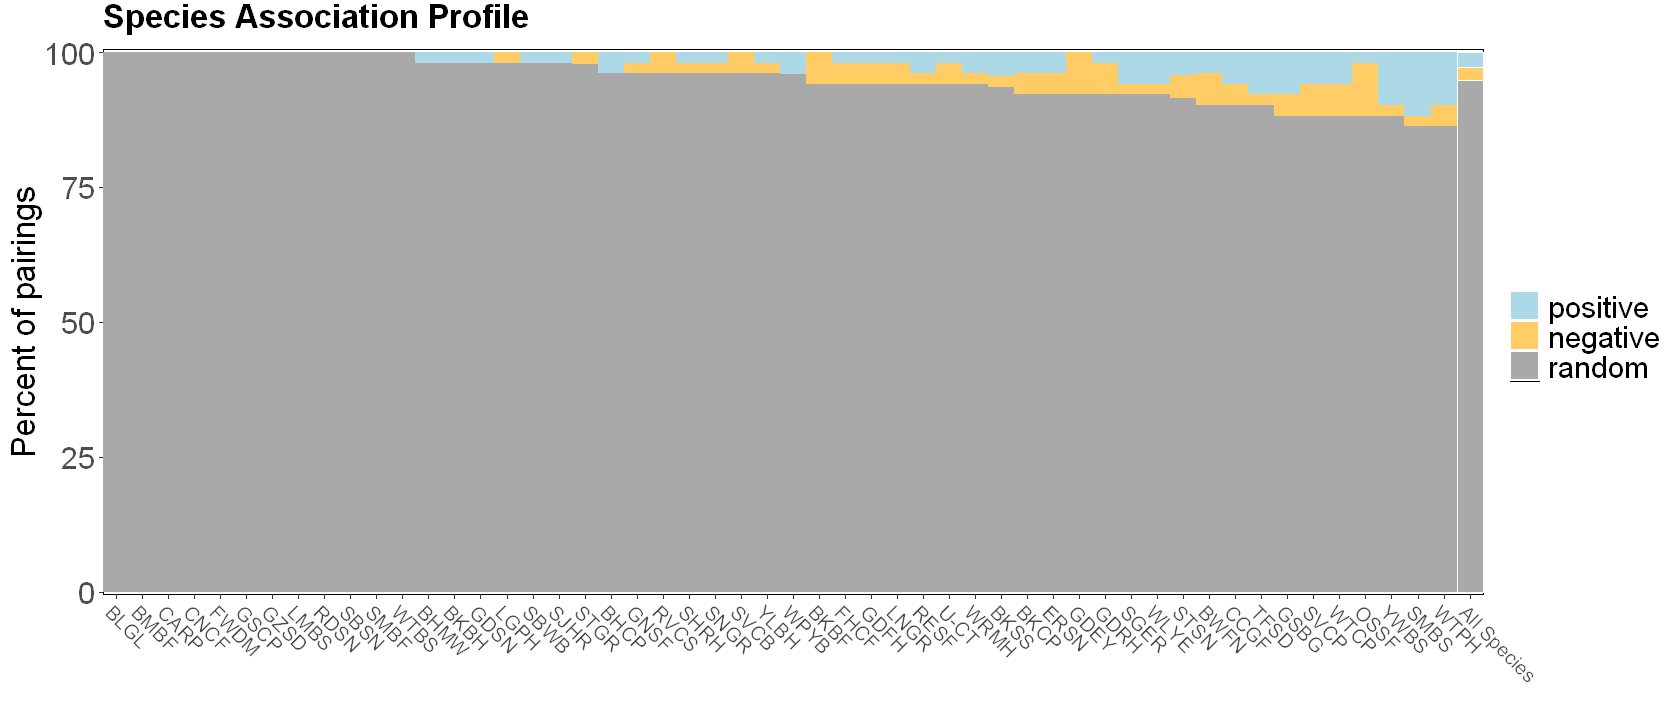

In [86]:
options(repr.plot.width = 14, repr.plot.height = 6)
pair.profile(result)

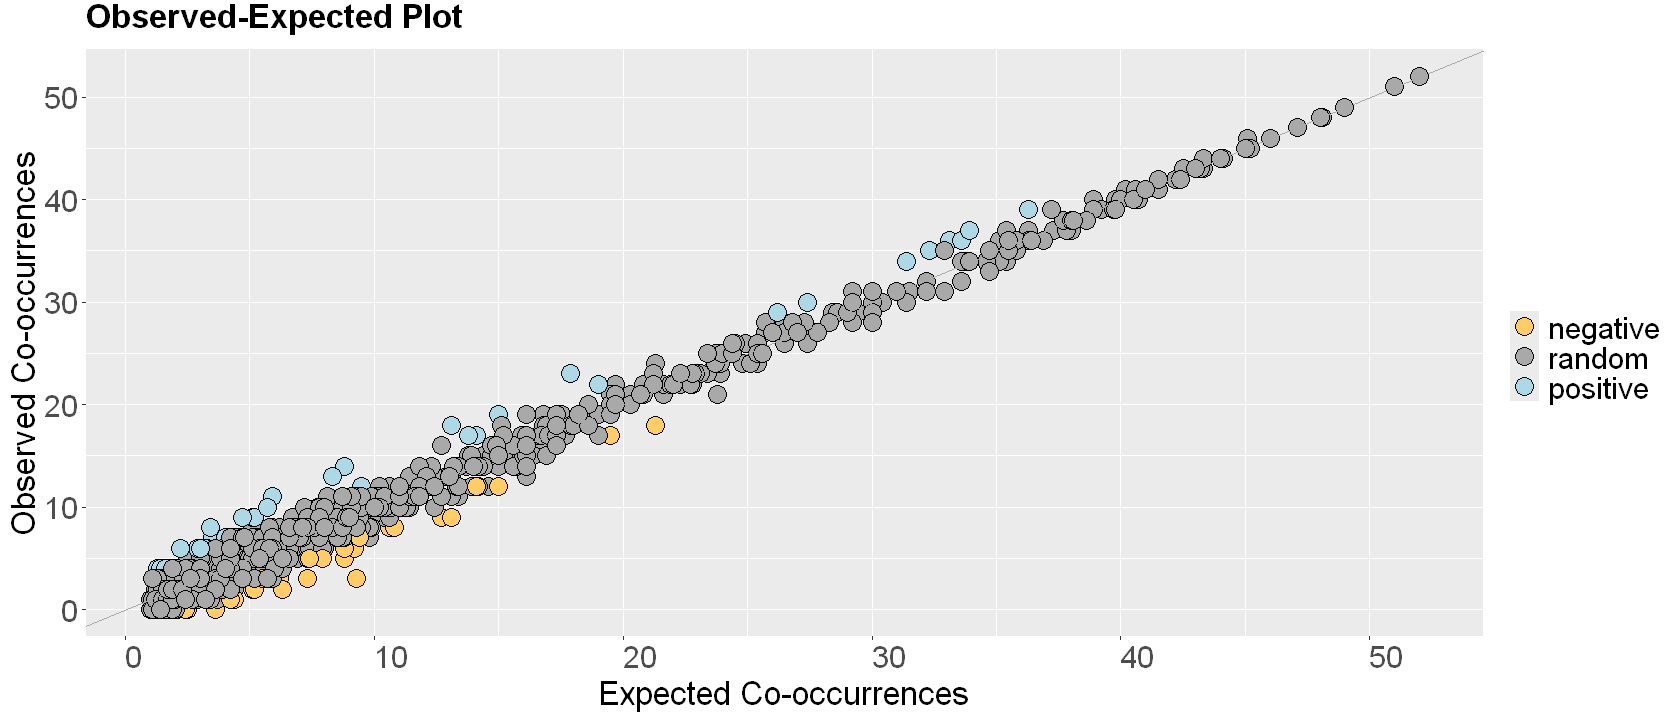

In [87]:
obs.v.exp(result) # observed vs expected co-occurrence comparison

In [88]:
round(effect.sizes(result,matrix=TRUE),3) # effect sizes (standardized residuals) for each species pair; values > 2 or < -2 indicate significant positive or negative associations, respectively

       BHCP   BHMW   BKBF   BKBH   BKCP   BKSS   BLGL   BMBF   BWFN   CARP
BHMW -0.006                                                               
BKBF -0.035 -0.042                                                        
BKBH  0.002 -0.013  0.006                                                 
BKCP -0.019  0.004  0.021 -0.019                                          
BKSS -0.019 -0.023 -0.021  0.000 -0.025                                   
BLGL -0.013  0.004 -0.010  0.004  0.017  0.002                            
BMBF  0.006  0.015  0.021 -0.006  0.010 -0.010 -0.002                     
BWFN  0.002 -0.025 -0.004  0.037  0.008  0.050  0.004 -0.021              
CARP  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000       
CCGF -0.023 -0.033  0.021 -0.006  0.042 -0.023  0.008  0.029 -0.046  0.000
CNCF  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000
ERSN -0.002 -0.013  0.023  0.002 -0.027  0.008 -0.004 -0.017  0.035  0.000
FHCF  0.000  0.023 -0.017

In [89]:
pair(mod = result, "SVCP", all=TRUE)  # pairwise stats for focal species

Species:
[1] "SVCP"
with 51 associations

      sp2 sp2_inc obs_cooccur prob_cooccur exp_cooccur    p_lt    p_gt
1261 TFSD      43          23        0.429        22.3 0.80485 0.44860
1262 U-CT      11          10        0.110         5.7 0.99978 0.00371
1263 WLYE      11           3        0.110         5.7 0.06578 0.98659
1264 WPYB       8           6        0.080         4.2 0.96755 0.15046
1265 WRMH      15           9        0.150         7.8 0.85280 0.33242
1266 WTBS      52          27        0.519        27.0 1.00000 1.00000
1267 WTCP      41          18        0.409        21.3 0.02698 0.99629
1268 WTPH      14           8        0.140         7.3 0.77871 0.44355
1269 YLBH       9           3        0.090         4.7 0.19515 0.94565
1270 YWBS      31          14        0.310        16.1 0.18348 0.92952
41   BHCP      17          14        0.170         8.8 0.99975 0.00236
91   BHMW      10           4        0.100         5.2 0.31303 0.88343
140  BKBF      27          14      

# Post-carp analysis ($> 2007$)

In [91]:
library(cooccur)

############################
# load data
############################
df2 <- read.csv("pres_abs.csv", header=TRUE)
ind <- which(df2[1,2:ncol(df2)] > 2007)+1 # before breakpoint
df2 <- df2[,c(1,ind)]
colnames(df2) <- paste(colnames(df2), df2[1, ], sep = "_")
df2 <- df2[3:nrow(df2), ]
rownames(df2) <- df2[,1]  
df2 <- df2[, -1]

df2 <- df2[rowSums(df2) > 0, ] # remove species with no occurrences
print(dim(df2))
print(df2[1:5, 1:5])

df2 <- df2[, colSums(df2) >= 25]    # reduces site count
df2 <- df2[rowSums(df2) >= 0.1*ncol(df2), ]   # reduces species count
print(dim(df2))

[1]  103 1261
     A11A.RS_2015 A13A.RS_2024 A14A.RS_2011 A19A.RS_2022 A22A.RS_2011
AMEL            0            0            0            0            0
BDKF            0            0            0            0            0
BGOS            0            0            0            0            0
BGRS            0            0            0            0            0
BGWM            0            0            0            0            0
[1]  50 110


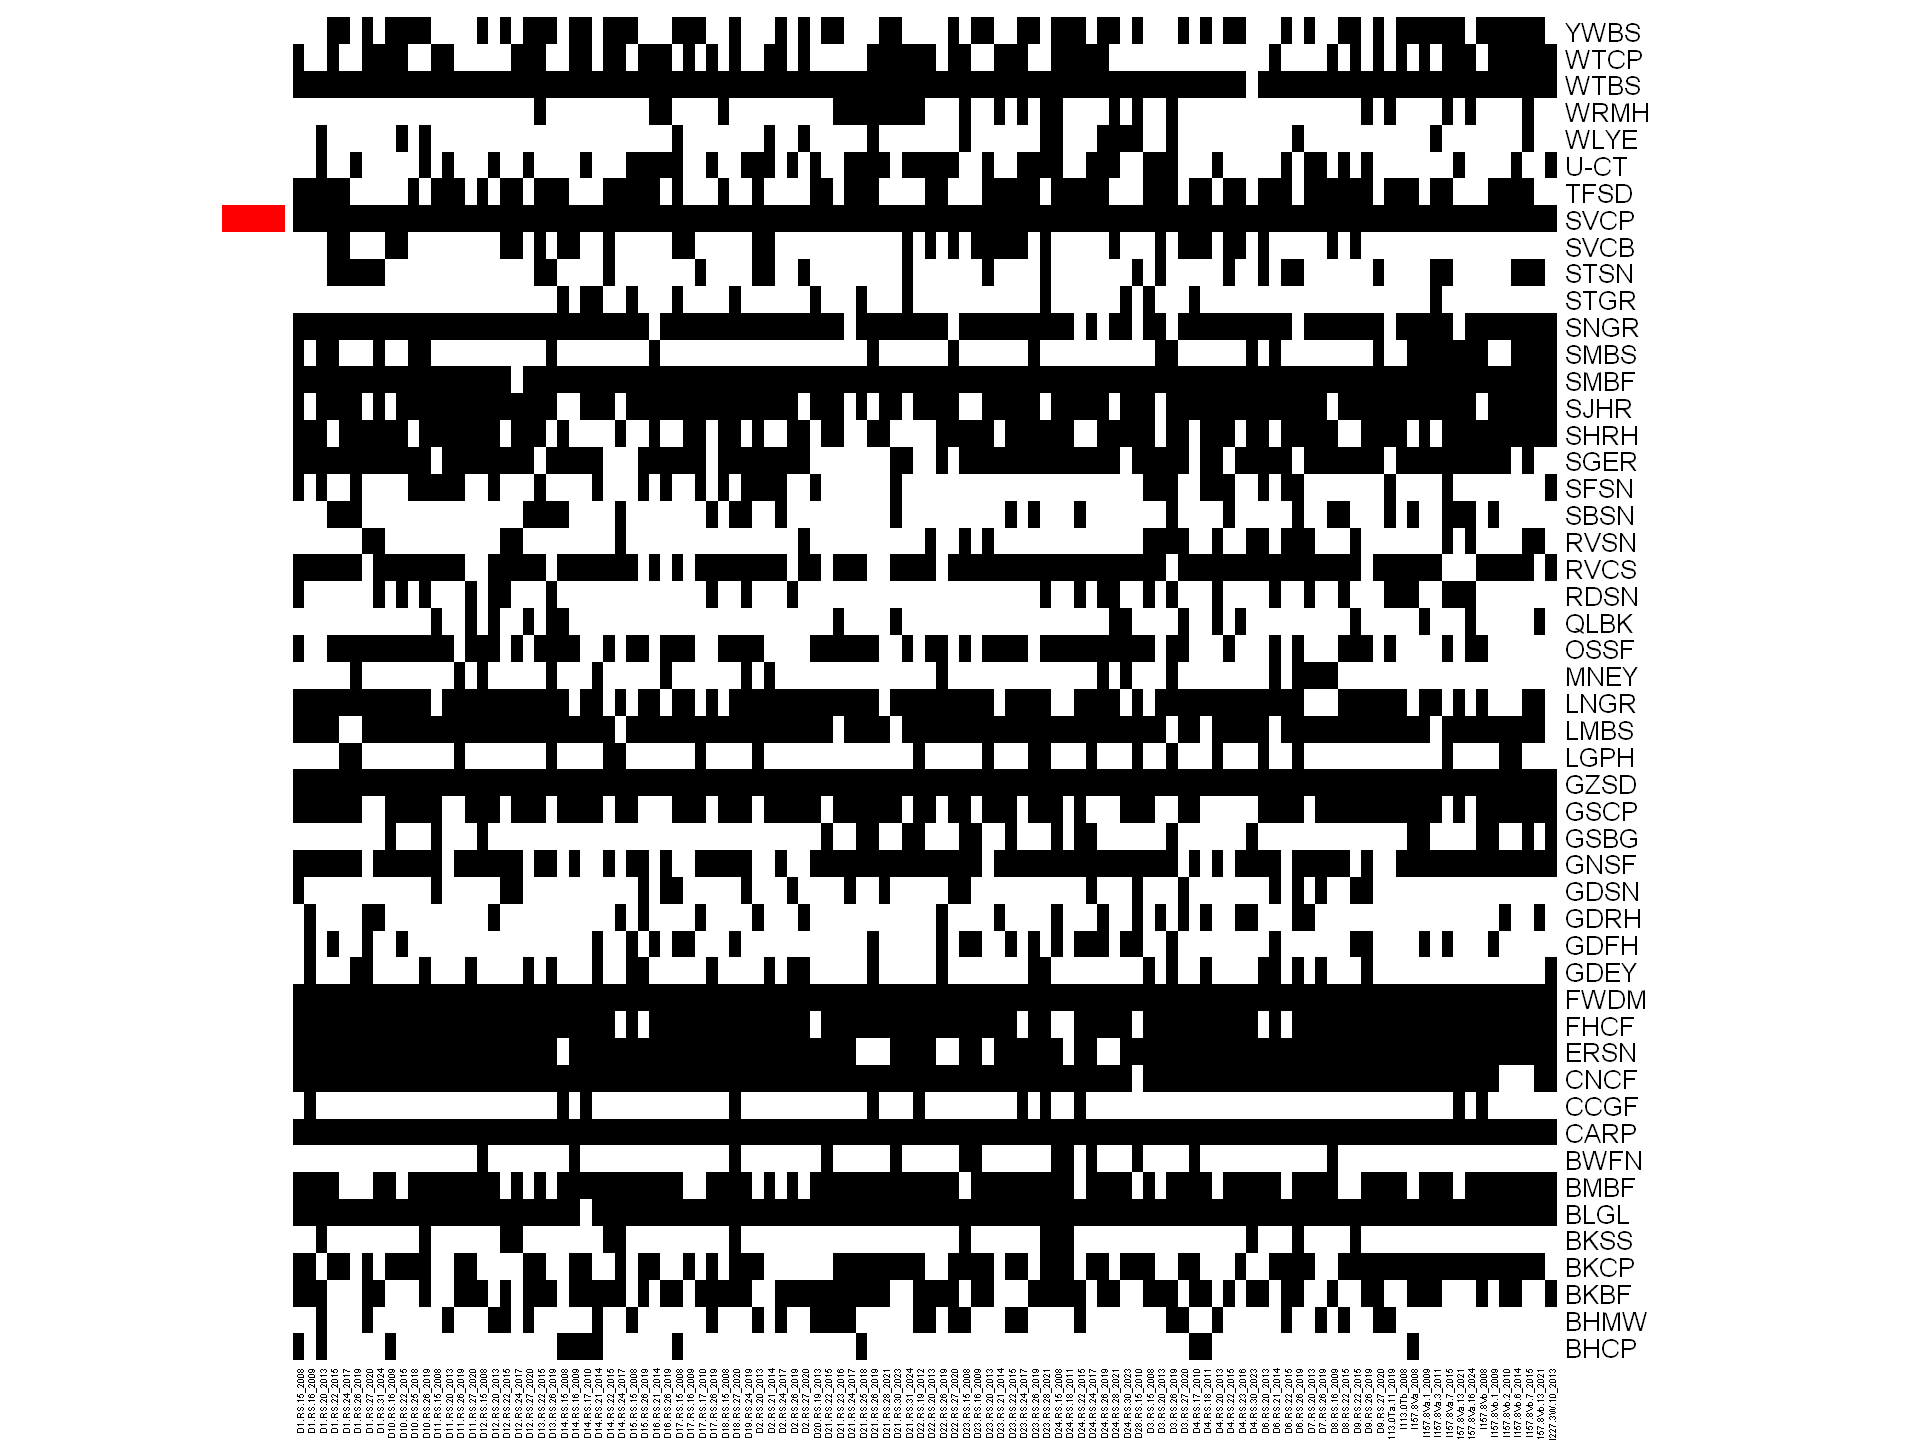

In [92]:
row_colors <- ifelse(rownames(df2) == "SVCP", "red", "white")
options(repr.plot.width = 16, repr.plot.height = 12)
heatmap(as.matrix(df2), col = c("white", "black"), scale = "none",
        Rowv = NA, Colv = NA, cexRow = 2.0, margins = c(5, 10),
        RowSideColors = row_colors)

In [93]:
result2 <- cooccur(mat = df2,
                  type = "spp_site",  # species in rows, sites in cols
                  thresh = TRUE,      # filter rare species pairs
                  spp_names = TRUE,  # use species names
                   true_rand_classifier = 0.1)  # use a more stringent threshold for classifying random pairs (default is 0.5)

summary(result2)  # summarize overall co-occurrence results


  |======================================================================| 100%
Call:
cooccur(mat = df2, type = "spp_site", thresh = TRUE, spp_names = TRUE, 
    true_rand_classifier = 0.1)

Of 1225 species pair combinations, 0 pairs (0 %) were removed from the analysis because expected co-occurrence was < 1 and 1225 pairs were analyzed

Cooccurrence Summary:


       Species          Sites       Positive       Negative         Random 
          50.0          110.0           32.0           46.0         1147.0 
Unclassifiable Non-random (%) 
           0.0            6.4 
attr(,"class")
[1] "summary.cooccur"

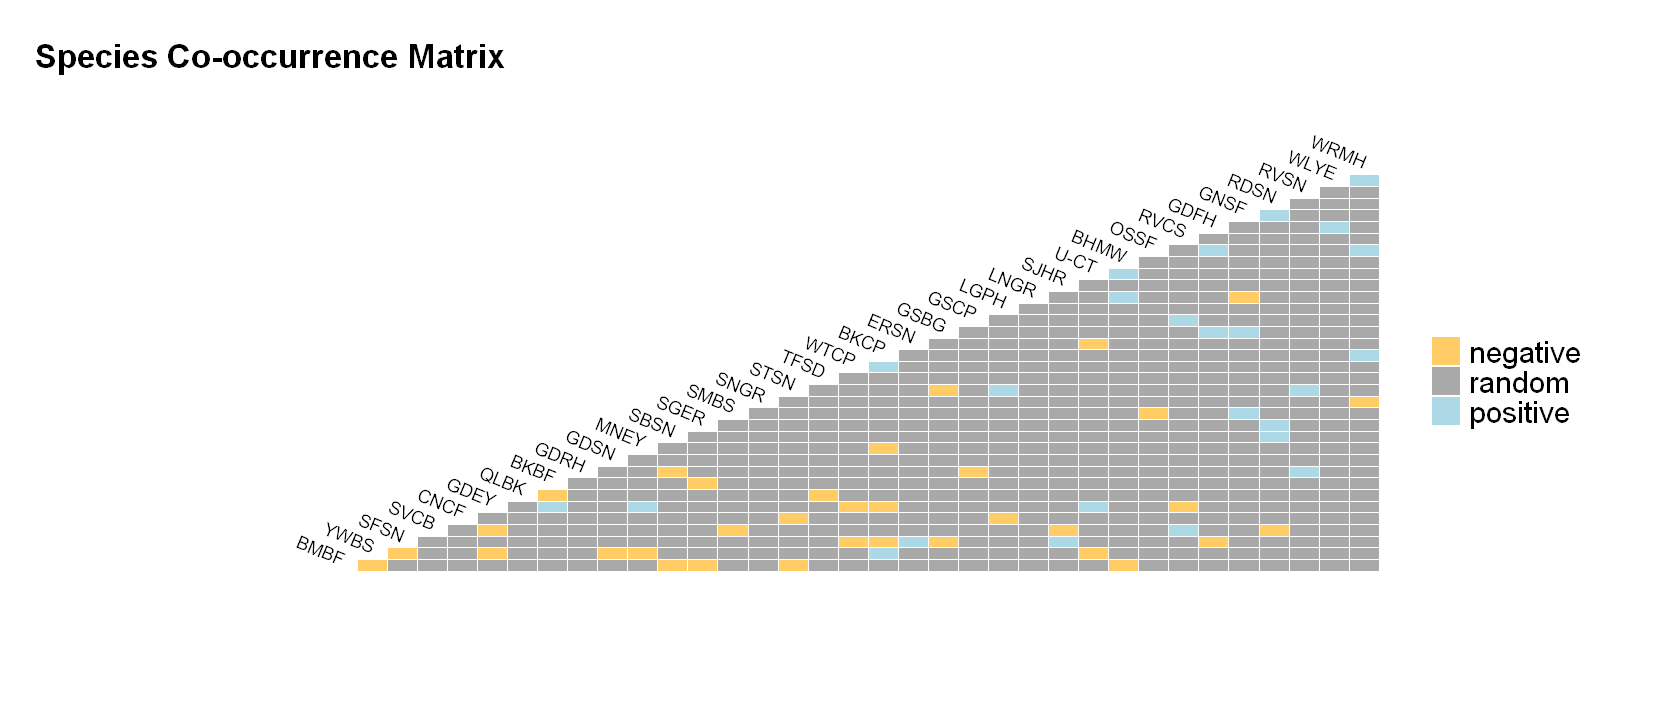

In [52]:
plot(result2)  # plot species pairwise co-occurrence patterns

In [46]:
# top 5 significant negative associations (p_lt = observed < or > expected)
prob.table(result2)[order(prob.table(result2)$p_lt), ][1:5, ]
prob.table(result2)[order(prob.table(result2)$p_gt), ][1:5, ]

Warning message in prob.table(result2):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"
Warning message in prob.table(result2):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"


,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
870,29,45,33,59,10,0.161,17.7,0.00126,0.99972,SFSN,YWBS
195,5,30,88,86,64,0.625,68.8,0.00223,1.00000,BMBF,SGER
113,3,29,70,33,14,0.191,21.0,0.00267,0.99935,BKCP,SFSN
531,15,21,88,87,65,0.633,69.6,0.00298,1.00000,GNSF,LNGR
429,11,45,27,59,8,0.132,14.5,0.00379,0.99912,GDEY,YWBS


Warning message in prob.table(result2):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"
Warning message in prob.table(result2):
"The co-occurrence model was run using 'thresh = TRUE.' The probability table may not include all species pairs"


,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
656,19,36,21,27,13,0.047,5.2,1.00000,0.00005,LGPH,STSN
526,15,16,88,22,22,0.160,17.6,1.00000,0.00398,GNSF,GSBG
406,11,22,27,17,9,0.038,4.2,0.99895,0.00584,GDEY,MNEY
476,13,27,23,24,10,0.046,5.0,0.99843,0.00743,GDRH,RVSN
828,27,36,24,27,11,0.054,5.9,0.99805,0.00848,RVSN,STSN


In [47]:
pair.attributes(result2) # result summary by species

,pos,neg,rand,num_pos,num_neg,num_rand,sppname
,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<chr>
1,4.55,2.27,93.18,2,1,41,BHMW
12,2.27,4.55,93.18,1,2,41,BKBF
23,6.82,6.82,86.36,3,3,38,BKCP
34,0.00,0.00,100.00,0,0,44,BLGL
41,0.00,11.36,88.64,0,5,39,BMBF
42,0.00,0.00,100.00,0,0,44,CARP
43,0.00,4.55,95.45,0,2,42,CNCF
44,2.27,2.27,95.45,1,1,42,ERSN
45,0.00,0.00,100.00,0,0,44,FHCF


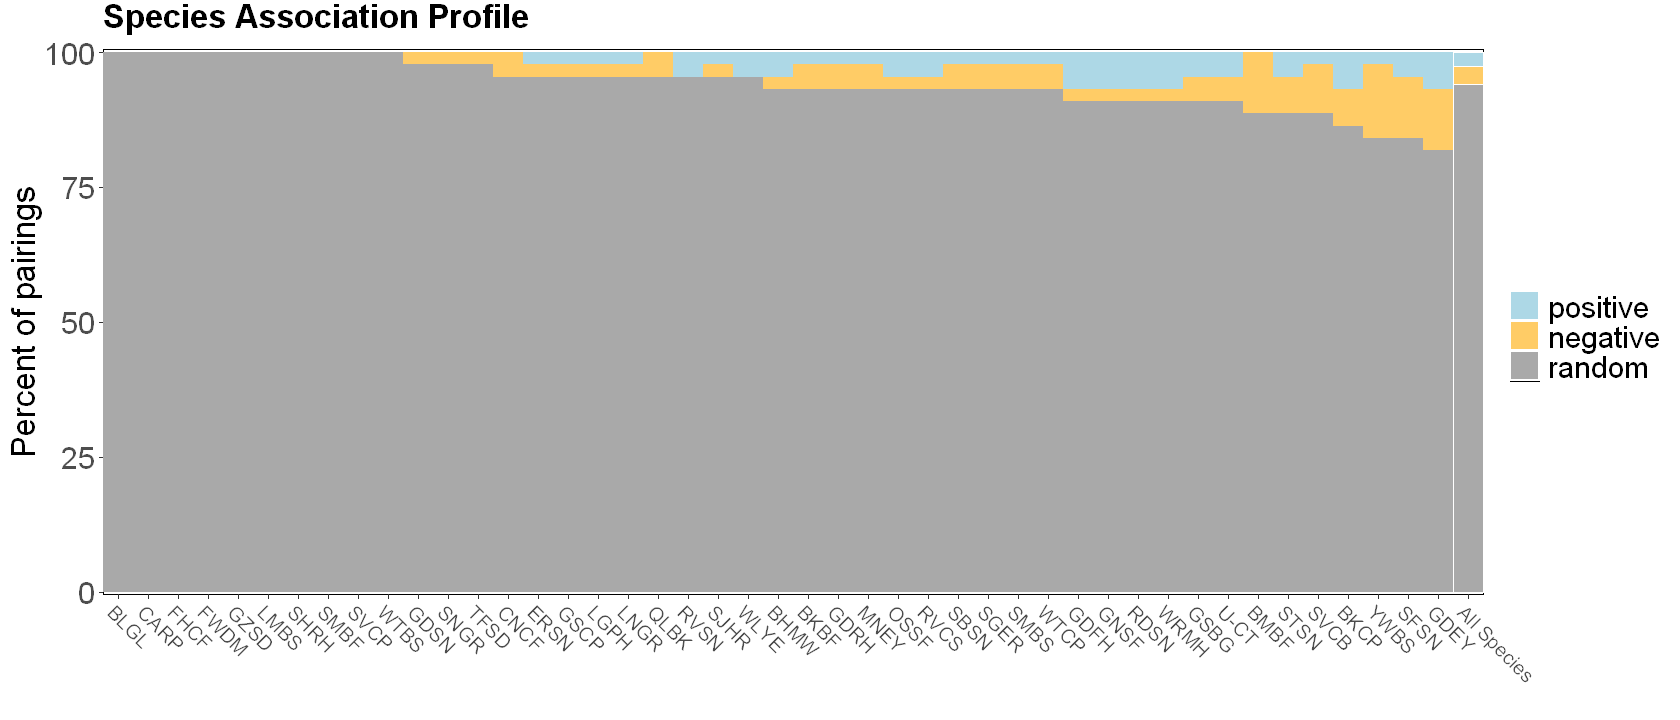

In [48]:
options(repr.plot.width = 14, repr.plot.height = 6)
pair.profile(result2)

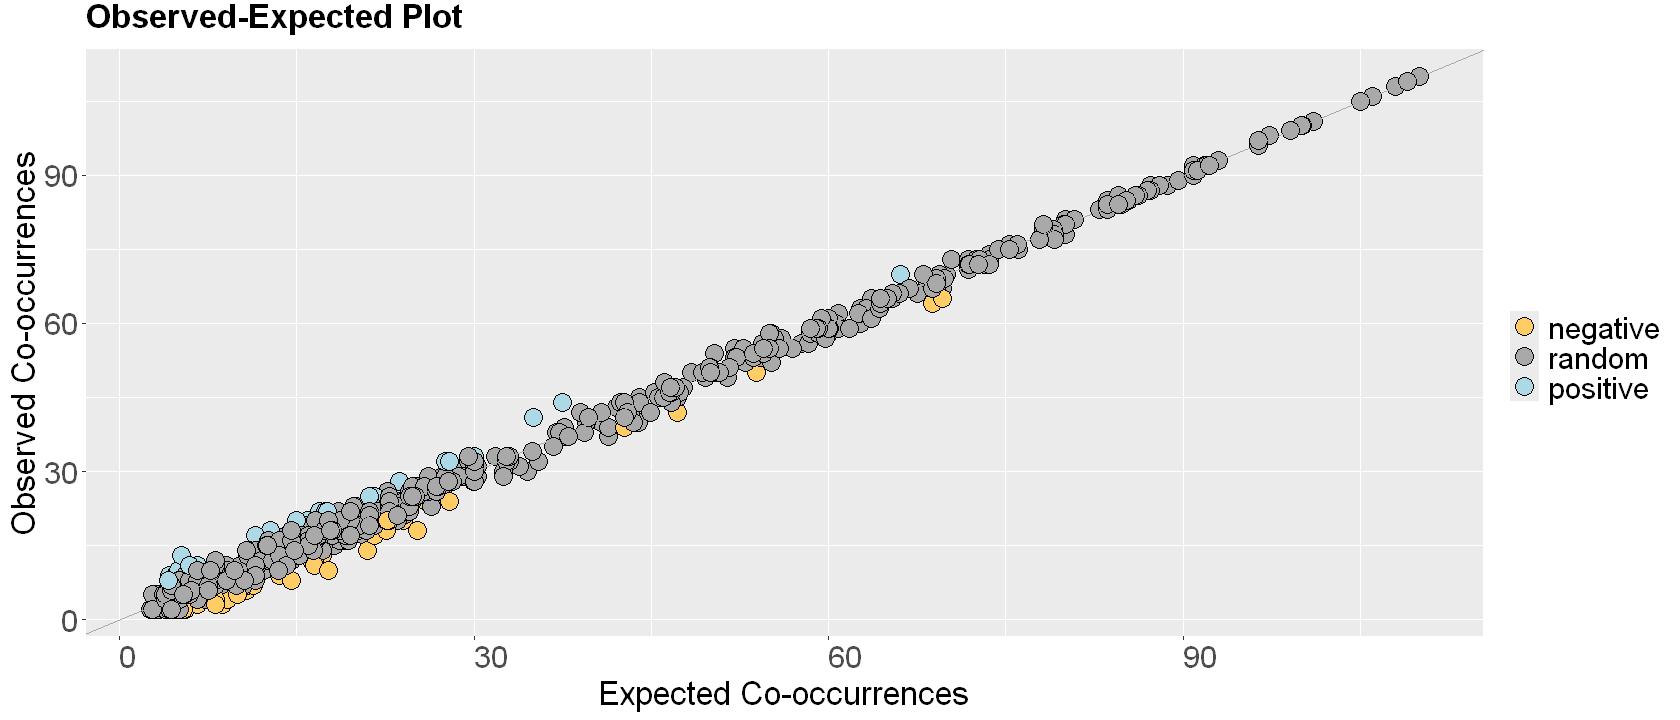

In [49]:
obs.v.exp(result2) # observed vs expected co-occurrence comparison

In [50]:
round(effect.sizes(result2,matrix=TRUE),3) # effect sizes (standardized residuals) for each species pair; values > 2 or < -2 indicate significant positive or negative associations, respectively

       BHMW   BKBF   BKCP   BLGL   BMBF   CARP   CNCF   ERSN   FHCF   FWDM
BKBF -0.007                                                               
BKCP -0.028 -0.035                                                        
BLGL  0.003 -0.004 -0.004                                                 
BMBF -0.036  0.025  0.009 -0.002                                          
CARP  0.000  0.000  0.000  0.000  0.000                                   
CNCF  0.010  0.005 -0.014  0.000  0.002  0.000                            
ERSN  0.015 -0.025 -0.005 -0.001 -0.018  0.000 -0.004                     
FHCF -0.005 -0.013 -0.012 -0.001  0.002  0.000  0.006  0.002              
FWDM  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000       
GDEY -0.004  0.046 -0.038  0.002  0.004  0.000  0.009  0.005  0.002  0.000
GDFH -0.008 -0.029  0.032  0.003 -0.011  0.000  0.001 -0.004  0.004  0.000
GDRH -0.021  0.005 -0.005  0.002 -0.013  0.000 -0.011  0.001 -0.019  0.000
GDSN  0.003 -0.011  0.005

In [51]:
pair(mod = result2, "SVCP", all=TRUE)  # pairwise stats for focal species

Species:
[1] "SVCP"
with 44 associations

     sp2 sp2_inc obs_cooccur prob_cooccur exp_cooccur p_lt p_gt
963 TFSD      65          65        0.591          65    1    1
964 U-CT      47          47        0.427          47    1    1
965 WLYE      18          18        0.164          18    1    1
966 WRMH      25          25        0.227          25    1    1
967 WTBS     109         109        0.991         109    1    1
968 WTCP      55          55        0.500          55    1    1
969 YWBS      59          59        0.536          59    1    1
37  BHMW      30          30        0.273          30    1    1
80  BKBF      69          69        0.627          69    1    1
122 BKCP      70          70        0.636          70    1    1
163 BLGL     109         109        0.991         109    1    1
203 BMBF      88          88        0.800          88    1    1
242 CARP     110         110        1.000         110    1    1
280 CNCF     106         106        0.964         106    1    